# Agentic RAG — Tool Routing Evaluation (v0)
## CS 6180 | Team 8

**What this notebook does:**
1. Builds a ChromaDB vector store from the Amazon FY2025 10-K (local knowledge base)
2. Routes each of the 28 Ollama-generated prompts through a Claude Sonnet router agent
3. The router retrieves top-k chunks from the vector store, then decides: `local` / `web` / `ambiguous`
4. Compares routing decisions against Ollama ground-truth labels
5. Plots accuracy, confusion matrix, and per-label breakdown

**Architecture (v0):**
```
Query
  │
  ├─► ChromaDB (10-K vector store)  ──► top-3 chunks
  │                                         │
  └─────────────────────────────────────────┤
                                            ▼
                                  Claude Sonnet Router
                                  (local | web | ambiguous)
                                            │
                                            ▼
                               Compare vs ground-truth label
```

---
## 0. Imports & Configuration

In [6]:
import json
import os
import re
import time
from getpass import getpass
from pathlib import Path

import chromadb
import fitz
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from tqdm import tqdm

# ── Config ─────────────────────────────────────────────────────────────────────
BASE_DIR        = Path("/Users/parinshah/Documents/NEU/Sem IV/GenAI/Project/MVP")
PDF_PATH        = BASE_DIR / "amzn_financial_report_2025.pdf"
OLLAMA_JSON     = BASE_DIR / "ollama.json"
RESULTS_CSV     = BASE_DIR / "routing_results_v0.csv"

CHUNK_CHARS     = 4_000
CHUNK_OVERLAP   = 0.20
TOP_K           = 3
ROUTER_MODEL    = "anthropic/claude-sonnet-4-5"   # slug from openrouter.ai/models
COLLECTION_NAME = "amzn_10k_v0"

# ── OpenRouter API key ─────────────────────────────────────────────────────────
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    OPENROUTER_API_KEY = getpass("Enter your OpenRouter API key: ")

# Verify key was captured
assert OPENROUTER_API_KEY, "API key is empty — re-run this cell and enter it."
print("✅ Config ready.")
print(f"   Router model : {ROUTER_MODEL}")
print(f"   Vector store : ChromaDB  (top-k={TOP_K})")
print(f"   Ground truth : {OLLAMA_JSON.name}")

✅ Config ready.
   Router model : anthropic/claude-sonnet-4-5
   Vector store : ChromaDB  (top-k=3)
   Ground truth : ollama.json


---
## 1. Load Ground-Truth Prompts (Ollama)

In [2]:
with open(OLLAMA_JSON) as f:
    gt_prompts = json.load(f)

gt_df = pd.DataFrame(gt_prompts)[["id", "prompt", "label", "reasoning"]]

print(f"Loaded {len(gt_df)} ground-truth prompts\n")
print(gt_df["label"].value_counts().to_string())
print()
gt_df.head(5)

Loaded 28 ground-truth prompts

label
local        15
ambiguous     7
web           6



,id,prompt,label,reasoning
0,1,What was Amazon's total revenue for the fiscal...,local,The answer can be found within the provided 10...
1,2,How has Amazon's AWS segment grown in terms of...,web,This question requires real-time or post-filin...
2,3,What is Amazon's latest update on employee hea...,ambiguous,The answer may be partially contained within t...
3,4,What are the primary risk factors that impact ...,local,The answer can be found within the provided 10...
4,5,Is Amazon currently facing any legal proceedin...,web,This question requires real-time or post-filin...


---
## 2. Build ChromaDB Vector Store from 10-K
Extract → chunk → embed → index. Skips rebuild if the collection already exists.

In [3]:
def extract_text(pdf_path: Path) -> str:
    doc = fitz.open(str(pdf_path))
    text = "\n".join(p.get_text() for p in doc)
    print(f"[PDF] {len(text):,} chars from {doc.page_count} pages")
    doc.close()
    return text


def make_chunks(text: str, size: int = CHUNK_CHARS,
                overlap: float = CHUNK_OVERLAP) -> list[str]:
    step = int(size * (1 - overlap))
    chunks = [text[i: i + size] for i in range(0, len(text), step)
              if text[i: i + size].strip()]
    print(f"[Chunker] {len(chunks)} chunks  ({size:,} chars, {overlap:.0%} overlap)")
    return chunks


def build_vector_store(chunks: list[str],
                       collection_name: str = COLLECTION_NAME) -> chromadb.Collection:
    """Embed and index all chunks into ChromaDB (in-memory).
    Uses all-MiniLM-L6-v2 via SentenceTransformer (no API key needed).
    """
    ef = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
    db = chromadb.Client()

    # Drop & recreate so re-runs are idempotent
    try:
        db.delete_collection(collection_name)
    except Exception:
        pass

    col = db.create_collection(collection_name, embedding_function=ef)

    # Upsert in batches of 100 to stay within memory limits
    batch = 100
    for i in tqdm(range(0, len(chunks), batch), desc="Indexing chunks"):
        batch_chunks = chunks[i: i + batch]
        col.upsert(
            ids=[str(i + j) for j in range(len(batch_chunks))],
            documents=batch_chunks,
        )

    print(f"[VectorStore] Indexed {col.count()} chunks into '{collection_name}'")
    return col


raw_text  = extract_text(PDF_PATH)
chunks    = make_chunks(raw_text)
vector_db = build_vector_store(chunks)

[PDF] 283,028 chars from 82 pages
[Chunker] 89 chunks  (4,000 chars, 20% overlap)


/Users/parinshah/miniforge3/envs/6180_proj/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9821.61it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Indexing chunks: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]

[VectorStore] Indexed 89 chunks into 'amzn_10k_v0'


---
## 3. Router Agent
For each query the router:
1. Retrieves the top-`k` most relevant chunks from ChromaDB
2. Passes the query + retrieved context to Claude Sonnet
3. Claude outputs exactly one label: `local`, `web`, or `ambiguous`

The retrieved context simulates what the local tool *would* return — letting the router make an informed decision rather than routing blind.

In [7]:
ROUTER_SYSTEM = """You are a tool-routing agent for an Agentic RAG system.
You have access to two information sources:
  1. LOCAL  — An indexed Amazon FY2025 10-K filing (annual report, fiscal year ended Dec 31 2025).
  2. WEB    — A live web search that can retrieve current news, real-time prices, and post-filing events.

Given a user query and excerpts retrieved from the local 10-K, decide which source best answers it.

ROUTING RULES:
- local     → The retrieved excerpts contain enough information to fully answer the query.
- web       → The query asks for real-time data (stock price, current news, recent regulatory actions)
              OR the retrieved excerpts clearly do NOT contain the answer.
- ambiguous → The excerpts partially answer the query but real-time context would also help,
              OR it is genuinely unclear which source is more appropriate.

OUTPUT: Respond with EXACTLY one word — either  local  or  web  or  ambiguous.
No explanation, no punctuation, no markdown. One word only."""


def retrieve(query: str, collection: chromadb.Collection, k: int = TOP_K) -> list[str]:
    """Return top-k document chunks most similar to the query."""
    results = collection.query(query_texts=[query], n_results=k)
    return results["documents"][0]


def call_openrouter(system: str, user: str) -> str:
    """POST to OpenRouter chat completions and return the response text."""
    resp = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": ROUTER_MODEL,
            "max_tokens": 16,
            "temperature": 0.0,
            "messages": [
                {"role": "system", "content": system},
                {"role": "user",   "content": user},
            ],
        },
        timeout=30,
    )
    resp.raise_for_status()
    return resp.json()["choices"][0]["message"]["content"].strip().lower()


def route(query: str, retrieved_chunks: list[str]) -> str:
    """Decide local / web / ambiguous for a query given retrieved context."""
    excerpts = "\n\n---\n\n".join(
        f"[Excerpt {i+1}]\n{chunk[:800]}" for i, chunk in enumerate(retrieved_chunks)
    )
    user_msg = f"""User query: {query}

Retrieved excerpts from the local 10-K:
{excerpts}

Based on the query and the retrieved excerpts above, output your routing decision (one word):"""

    raw = call_openrouter(ROUTER_SYSTEM, user_msg)

    for label in ("local", "web", "ambiguous"):
        if label in raw:
            return label
    return "ambiguous"   # safe fallback


# Quick smoke test
_test_q      = "What was Amazon's total revenue for fiscal year 2025?"
_test_chunks = retrieve(_test_q, vector_db)
_test_label  = route(_test_q, _test_chunks)
print(f"Smoke test query : {_test_q}")
print(f"Router decision  : {_test_label}")
print(f"Retrieved snippet: {_test_chunks[0][:120]}...")

Smoke test query : What was Amazon's total revenue for fiscal year 2025?
Router decision  : local
Retrieved snippet: idance
We provided guidance on February 5, 2026, in our earnings release furnished on Form 8-K as set forth below. These...


---
## 4. Batch Routing Run
Route all 28 Ollama prompts and record each decision alongside the ground-truth label.

In [8]:
records = []

for _, row in tqdm(gt_df.iterrows(), total=len(gt_df), desc="Routing"):
    query      = row["prompt"]
    gt_label   = row["label"]

    try:
        chunks_ret    = retrieve(query, vector_db)
        routed_label  = route(query, chunks_ret)
        top_snippet   = chunks_ret[0][:120].replace("\n", " ")
    except Exception as e:
        routed_label = "error"
        top_snippet  = str(e)[:120]

    correct = (routed_label == gt_label)
    records.append({
        "id"           : row["id"],
        "prompt"       : query,
        "gt_label"     : gt_label,
        "routed_label" : routed_label,
        "correct"      : correct,
        "top_snippet"  : top_snippet,
    })

    time.sleep(0.3)   # gentle rate-limit buffer

results_df = pd.DataFrame(records)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"\n✅ Routing complete — saved to {RESULTS_CSV.name}")
results_df[["id", "prompt", "gt_label", "routed_label", "correct"]].head(10)

Routing: 100%|██████████| 28/28 [00:52<00:00,  1.88s/it]


✅ Routing complete — saved to routing_results_v0.csv


,id,prompt,gt_label,routed_label,correct
0,1,What was Amazon's total revenue for the fiscal...,local,local,True
1,2,How has Amazon's AWS segment grown in terms of...,web,web,True
2,3,What is Amazon's latest update on employee hea...,ambiguous,ambiguous,True
3,4,What are the primary risk factors that impact ...,local,local,True
4,5,Is Amazon currently facing any legal proceedin...,web,local,False
5,6,What are some of the key products and services...,local,local,True
6,7,What is Amazon's current market capitalization...,web,web,True
7,8,How does Amazon's competition in the e-commerc...,local,local,True
8,9,What are Amazon's most recent efforts to addre...,ambiguous,web,False
9,10,How has Amazon's international expansion impac...,local,local,True


---
## 5. Evaluation Metrics
Overall accuracy + per-label precision, recall, and F1.

In [9]:
LABELS = ["local", "web", "ambiguous"]

def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-label precision, recall, F1, and support."""
    rows = []
    for lbl in LABELS:
        tp = ((df["gt_label"] == lbl) & (df["routed_label"] == lbl)).sum()
        fp = ((df["gt_label"] != lbl) & (df["routed_label"] == lbl)).sum()
        fn = ((df["gt_label"] == lbl) & (df["routed_label"] != lbl)).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)
        support   = (df["gt_label"] == lbl).sum()
        rows.append(dict(label=lbl, precision=precision,
                         recall=recall, f1=f1, support=support))
    return pd.DataFrame(rows).set_index("label")


overall_acc = results_df["correct"].mean()
metrics_df  = compute_metrics(results_df)

print(f"{'='*45}")
print(f"  Overall Routing Accuracy : {overall_acc:.1%}  ({results_df['correct'].sum()}/{len(results_df)})")
print(f"{'='*45}\n")
print(metrics_df.round(3).to_string())
print()

# Label distribution comparison
gt_counts  = results_df["gt_label"].value_counts().reindex(LABELS, fill_value=0)
rt_counts  = results_df["routed_label"].value_counts().reindex(LABELS, fill_value=0)
dist_df    = pd.DataFrame({"ground_truth": gt_counts, "routed": rt_counts})
print("\nLabel distribution — ground truth vs routed:")
print(dist_df.to_string())

  Overall Routing Accuracy : 60.7%  (17/28)

           precision  recall     f1  support
label                                       
local          0.706   0.800  0.750       15
web            0.600   0.500  0.545        6
ambiguous      0.333   0.286  0.308        7


Label distribution — ground truth vs routed:
           ground_truth  routed
local                15      17
web                   6       5
ambiguous             7       6


---
## 6. Confusion Matrix

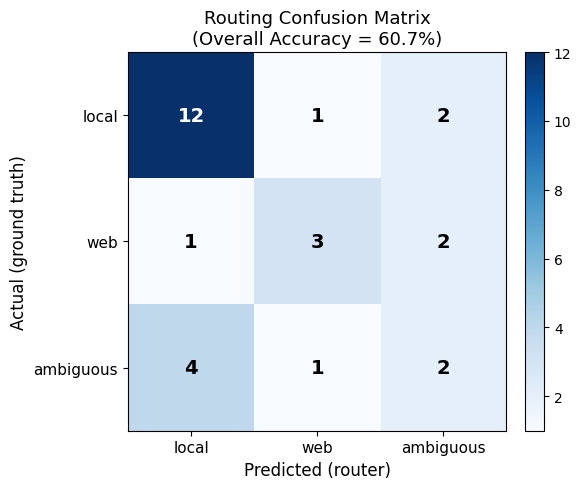

In [10]:
def plot_confusion_matrix(df: pd.DataFrame, labels: list[str]) -> None:
    """Heatmap: rows = ground truth, cols = router prediction."""
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    label_idx = {l: i for i, l in enumerate(labels)}

    for _, row in df.iterrows():
        gt  = row["gt_label"]
        rt  = row["routed_label"]
        if gt in label_idx and rt in label_idx:
            cm[label_idx[gt]][label_idx[rt]] += 1

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Predicted (router)", fontsize=12)
    ax.set_ylabel("Actual (ground truth)", fontsize=12)
    ax.set_title(f"Routing Confusion Matrix\n(Overall Accuracy = {overall_acc:.1%})",
                 fontsize=13)

    # Annotate cells
    for i in range(len(labels)):
        for j in range(len(labels)):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=14, fontweight="bold", color=color)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(BASE_DIR / "confusion_matrix_v0.png", dpi=150)
    plt.show()


plot_confusion_matrix(results_df, LABELS)

---
## 7. Visualisations
Three panels: per-label accuracy, precision/recall/F1 comparison, and label distribution drift (ground truth vs routed).

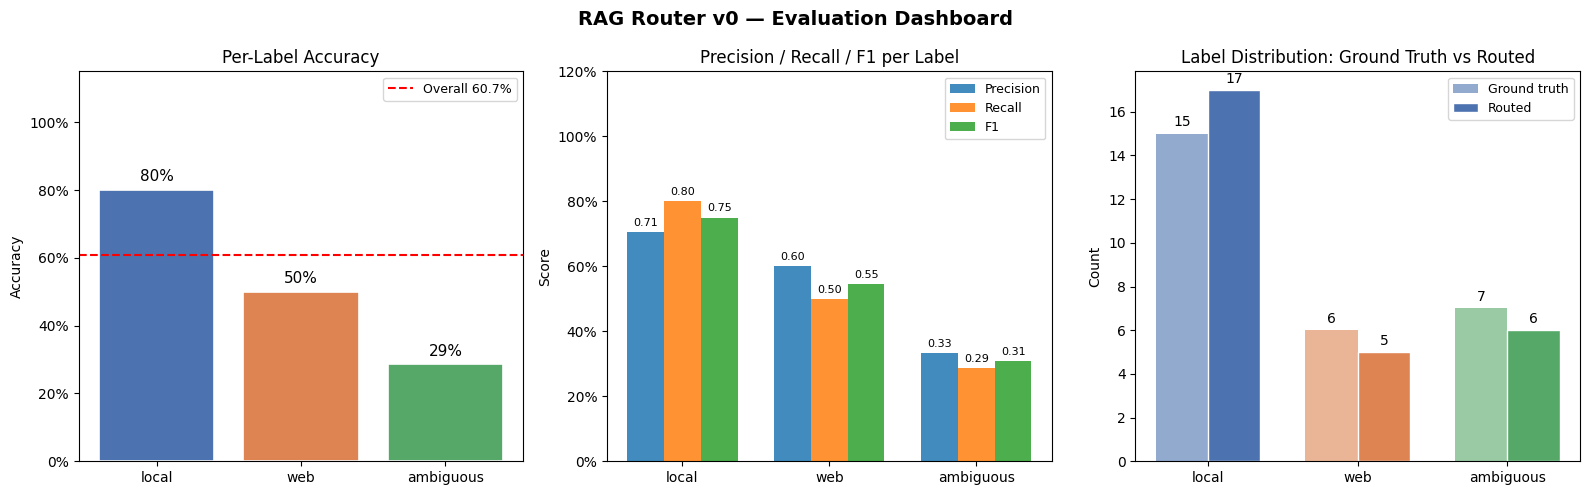

Saved → routing_dashboard_v0.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("RAG Router v0 — Evaluation Dashboard", fontsize=14, fontweight="bold")

COLORS = {"local": "#4C72B0", "web": "#DD8452", "ambiguous": "#55A868"}

# ── Panel 1: Per-label accuracy ───────────────────────────────────────────────
ax1 = axes[0]
per_label_acc = (
    results_df.groupby("gt_label")["correct"]
    .agg(["sum", "count"])
    .reindex(LABELS, fill_value=0)
)
per_label_acc["accuracy"] = per_label_acc["sum"] / per_label_acc["count"]

bars = ax1.bar(
    LABELS,
    per_label_acc["accuracy"],
    color=[COLORS[l] for l in LABELS],
    edgecolor="white", linewidth=1.2
)
ax1.axhline(overall_acc, color="red", linestyle="--", linewidth=1.5,
            label=f"Overall {overall_acc:.1%}")
ax1.bar_label(bars, fmt=lambda v: f"{v:.0%}", padding=4, fontsize=11)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Accuracy")
ax1.set_title("Per-Label Accuracy")
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# ── Panel 2: Precision / Recall / F1 ─────────────────────────────────────────
ax2 = axes[1]
x   = np.arange(len(LABELS))
w   = 0.25
for i, (metric, offset) in enumerate(zip(["precision", "recall", "f1"],
                                          [-w, 0, w])):
    vals = metrics_df[metric].reindex(LABELS).values
    b    = ax2.bar(x + offset, vals, w, label=metric.title(), alpha=0.85)
    ax2.bar_label(b, fmt=lambda v: f"{v:.2f}", padding=3, fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(LABELS)
ax2.set_ylim(0, 1.2)
ax2.set_ylabel("Score")
ax2.set_title("Precision / Recall / F1 per Label")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# ── Panel 3: Label distribution drift ────────────────────────────────────────
ax3    = axes[2]
x      = np.arange(len(LABELS))
w      = 0.35
b_gt   = ax3.bar(x - w/2, gt_counts.values, w, label="Ground truth",
                 color=[COLORS[l] for l in LABELS], alpha=0.6)
b_rt   = ax3.bar(x + w/2, rt_counts.values, w, label="Routed",
                 color=[COLORS[l] for l in LABELS], alpha=1.0, edgecolor="white")
ax3.bar_label(b_gt, padding=3, fontsize=10)
ax3.bar_label(b_rt, padding=3, fontsize=10)
ax3.set_xticks(x)
ax3.set_xticklabels(LABELS)
ax3.set_ylabel("Count")
ax3.set_title("Label Distribution: Ground Truth vs Routed")
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / "routing_dashboard_v0.png", dpi=150)
plt.show()
print(f"Saved → routing_dashboard_v0.png")

---
## 8. Failure Analysis
Inspect every mis-routed prompt — what did the router predict and why might it have gone wrong?

In [12]:
wrong_df = results_df[~results_df["correct"]].reset_index(drop=True)

print(f"Mis-routed prompts: {len(wrong_df)} / {len(results_df)}\n")
print(f"{'─'*80}")
for _, row in wrong_df.iterrows():
    print(f"[ID {row['id']:>2}]  GT={row['gt_label']:<10}  Routed={row['routed_label']:<10}")
    print(f"       Prompt : {row['prompt']}")
    print(f"       Snippet: {row['top_snippet'][:100]}...")
    print()

Mis-routed prompts: 11 / 28

────────────────────────────────────────────────────────────────────────────────
[ID  5]  GT=web         Routed=local     
       Prompt : Is Amazon currently facing any legal proceedings or regulatory actions that could impact its business?
       Snippet: cember 2018, Kove IO, Inc. filed a complaint against Amazon Web Services, Inc. in the United States ...

[ID  9]  GT=ambiguous   Routed=web       
       Prompt : What are Amazon's most recent efforts to address climate change and sustainability in its operations?
       Snippet: cers Name Age Position Jeffrey P. Bezos 62 Executive Chair Andrew R. Jassy 58 President and Chief Ex...

[ID 12]  GT=ambiguous   Routed=local     
       Prompt : Is Amazon still using AWS for its cloud infrastructure?
       Snippet: sales, the mix of sales by third-party sellers, the mix of suppliers, seasonality, and changes in pa...

[ID 14]  GT=local       Routed=web       
       Prompt : How many employees does Amazon hav

In [13]:
# Error pattern breakdown — which (gt → routed) transitions are most common?
error_patterns = (
    wrong_df.groupby(["gt_label", "routed_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Most common mis-routing patterns (ground_truth → predicted):")
print(error_patterns.to_string(index=False))

Most common mis-routing patterns (ground_truth → predicted):
 gt_label routed_label  count
ambiguous        local      4
    local    ambiguous      2
      web    ambiguous      2
ambiguous          web      1
    local          web      1
      web        local      1


---
## 9. Summary

| Metric | Value |
|---|---|
| Total prompts evaluated | 28 (Ollama ground truth) |
| Vector store | ChromaDB · all-MiniLM-L6-v2 · full 10-K |
| Router | Claude Sonnet 4.6 · retrieval-augmented |
| Top-k chunks per query | 3 |

**Key observations to note after running:**
- Where does the router struggle most — `ambiguous` queries are hardest by design
- Compare per-label accuracy: `local` should be highest (clearest signal from retrieved chunks)
- Mis-routing patterns: does the router over-predict `local` (overconfident in retrieval) or `web`?

**v1 improvements to consider:**
- Increase `TOP_K` for ambiguous queries
- Add a confidence score / threshold before routing
- Use LangGraph to support multi-hop routing decisions